<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-12</br>
</div>

</br>

In [23]:
# TODO 0: 실습을 위해 아래 패키지를 import하고, iris 데이터셋과 로지스틱 회귀 함수를 준비해주세요.
import numpy as np
import seaborn as sns
from itertools import product
import matplotlib.pyplot as plt

# iris 데이터셋 로드 (이진 분류: virginica vs 나머지)
df = sns.load_dataset("iris")
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[feature_cols].values
y = (df["species"] == "virginica").astype(int).values

# 표준화
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_std = np.where(X_std == 0, 1.0, X_std)
X = (X - X_mean) / X_std

# Train/Valid 분할 (80:20)
dataset_count = len(X)
shuffled_index = np.random.permutation(dataset_count)
cut_index = int(dataset_count * 0.8)
X_train, X_valid = X[shuffled_index[:cut_index]], X[shuffled_index[cut_index:]]
y_train, y_valid = y[shuffled_index[:cut_index]], y[shuffled_index[cut_index:]]

# 로지스틱 회귀 기본 함수 (006에서 학습한 내용)
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def predict_probability(X, W, b):
    return sigmoid(X @ W + b)

def binary_cross_entropy(y, p, epsilon=1e-12):
    p = np.clip(p, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def accuracy(X, W, b, y):
    return np.mean((predict_probability(X, W, b) >= 0.5) == y)

# 초기화
W = np.zeros(X_train.shape[1])
b = 0.0
learning_rate = 0.1
l2 = 0.01

print(f"데이터: iris ({len(X)}개, 이진 분류: virginica vs 나머지)")
print(f"피처: {feature_cols}")
print(f"Train: {len(X_train)}개, Valid: {len(X_valid)}개")

데이터: iris (150개, 이진 분류: virginica vs 나머지)
피처: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Train: 120개, Valid: 30개


</br>

# 학습 내용
>이번 장에서는 <strong>L2 정규화(L2 Regularization)</strong>에 대해 학습합니다.</br></br>
>과적합 방지를 위한 정규화 기법과 하이퍼파라미터 실험 방법을 학습해봅시다.

</br>

# 과적합 (Overfitting)
> 모델이 학습 데이터에 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">너무 맞춰져서</mark> 새로운 데이터에 대한 성능이 떨어지는 현상입니다.

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">상태</th>
      <th style="text-align:center">Train 성능</th>
      <th style="text-align:center">Validation 성능</th>
      <th style="text-align:center">파라미터 크기</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">과소적합</td><td style="text-align:center">낮음</td><td style="text-align:center">낮음</td><td style="text-align:center">작음</td></tr>
    <tr><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">적절한 학습</mark></td><td style="text-align:center">높음</td><td style="text-align:center">높음</td><td style="text-align:center">적절함</td></tr>
    <tr><td style="text-align:center">과적합</td><td style="text-align:center">매우 높음</td><td style="text-align:center">낮음</td><td style="text-align:center">매우 큼</td></tr>
  </tbody>
</table>

💡과적합 징후
> Train Loss는 계속 감소하는데 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Validation Loss가 증가</mark>하기 시작하면 과적합입니다.</br>
> 파라미터 값이 비정상적으로 커지는 것도 과적합의 신호입니다.

</br>

# L2 정규화란?
> 손실 함수에 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">파라미터 크기에 대한 벌점</mark>을 추가하여 과적합을 방지합니다.

$$L_{\text{total}} = L_{\text{BCE}} + \frac{\lambda}{2} \|W\|_2^2$$

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">수식</th>
      <th style="text-align:center">코드</th>
      <th>의미</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">$\lambda$</td><td style="text-align:center"><code>l2</code></td><td>정규화 강도 (하이퍼파라미터)</td></tr>
    <tr><td style="text-align:center">$\frac{1}{2}$</td><td style="text-align:center"><code>0.5</code></td><td>미분 시 계수를 깔끔하게 만드는 상수</td></tr>
    <tr><td style="text-align:center">$\|W\|_2^2$</td><td style="text-align:center"><code>np.sum(W ** 2)</code></td><td>가중치 제곱의 합</td></tr>
  </tbody>
</table>

💡왜 $\frac{1}{2}$을 곱할까?

> $W$로 미분하면: $\frac{\partial}{\partial W}\left(\frac{\lambda}{2} W^2\right) = \lambda W$</br>
> $\frac{1}{2}$이 제곱의 미분에서 나오는 2와 상쇄되어 그래디언트가 $\lambda W$로 깔끔해집니다.</br>
> $\frac{1}{2}$이 없으면 $2\lambda W$가 되어 불필요하게 복잡해집니다.

In [24]:
# TODO 1:
#  - predict_probability 함수로 훈련 데이터의 예측 확률을 구해봅시다.
#  - binary_cross_entropy 함수로 BCE 손실을 계산해봅시다.
#  - L2 페널티를 계산해봅시다. (0.5 * λ * ||W||²)
#  - BCE 손실과 L2 페널티를 더하여 전체 손실을 구해봅시다.

p = predict_probability(X_train, W, b)
bce_loss = binary_cross_entropy(y_train, p)
l2_penalty = 0.5 * l2 * np.sum(W ** 2)
loss = bce_loss + l2_penalty

print(f"BCE Loss: {bce_loss:.4f}")
print(f"L2 Penalty: {l2_penalty:.4f}")
print(f"Total Loss: {loss:.4f}")

BCE Loss: 0.6931
L2 Penalty: 0.0000
Total Loss: 0.6931


💡왜 편향(b)에는 정규화를 적용하지 않을까?
> 편향은 모델의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">기본 위치(offset)</mark>를 결정합니다.</br>
> 편향에 벌점을 주면 데이터의 평균적 특성을 학습하기 어려워집니다.</br>
> 정규화는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">가중치(W)에만</mark> 적용하는 것이 일반적입니다.

</br>

# 정규화된 그래디언트
> L2 정규화를 적용하면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">가중치 그래디언트에 $\lambda W$ 항이 추가</mark>됩니다.

$$\nabla_W = \frac{1}{m} X^T (\hat{p} - y) + \lambda W$$

$$\nabla_b = \frac{1}{m} \sum_{i=1}^{m} (\hat{p}_i - y_i)$$

In [25]:
# TODO 2: L2 정규화가 포함된 그래디언트 계산 함수를 정의해봅시다.

def compute_gradients_l2(X, y, p, W, l2=0.0):

    # TODO 2-1: 샘플 수를 m에 저장해봅시다.
    m = len(y)

    # TODO 2-2: 예측과 실제의 차이(p - y)를 diff에 저장해봅시다.
    diff = p - y

    # TODO 2-3: 가중치 그래디언트를 계산하고, L2 항(λW)을 추가해봅시다.
    gradient_W = (1 / m) * X.T @ diff + l2 * W

    # TODO 2-4: 편향 그래디언트를 계산해봅시다. (정규화 없음)
    gradient_b = (1 / m) * np.sum(diff)

    # TODO 2-5: gradient_W와 gradient_b를 반환해봅시다.
    return gradient_W, gradient_b

💡정규화의 효과
> 가중치 업데이트: $W \leftarrow W - \alpha(\nabla_W + \lambda W) = W(1 - \alpha\lambda) - \alpha\nabla_W$</br>
> 매 업데이트마다 가중치가 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">$(1 - \alpha\lambda)$배로 축소</mark>됩니다.</br>
> 이를 **가중치 감쇠(Weight Decay)**라고도 부릅니다.

</br>

# 정규화 강도 $\lambda$ 선택

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">$\lambda$ 값</th>
      <th>효과</th>
      <th>위험</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">0</td><td>정규화 없음</td><td>과적합 가능</td></tr>
    <tr><td style="text-align:center">0.001~0.01</td><td>약한 정규화</td><td>-</td></tr>
    <tr><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">0.01~0.1</mark></td><td>적절한 정규화</td><td>-</td></tr>
    <tr><td style="text-align:center">1.0 이상</td><td>강한 정규화</td><td>과소적합 가능</td></tr>
  </tbody>
</table>

</br>

# 하이퍼파라미터 실험 (Grid Search)
> 여러 하이퍼파라미터 조합을 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">체계적으로 탐색</mark>하여 최적 설정을 찾습니다.

In [26]:
# TODO 3:
#  - 실험할 학습률 목록을 learning_rates에 저장해봅시다. [0.1, 0.01]
#  - 실험할 L2 정규화 강도 목록을 l2_strengths에 저장해봅시다. [0.0, 0.1]
#  - 실험할 그래디언트 누적 횟수 목록을 accumulate_steps에 저장해봅시다. [1, 2]
#  - product를 사용하여 모든 조합을 생성해봅시다.

from itertools import product

learning_rates = [0.1, 0.01]
l2_strengths = [0.0, 0.1]
accumulate_steps = [1, 2]
experiments = list(product(learning_rates, l2_strengths, accumulate_steps))

print(f"총 실험 수: {len(experiments)}")
for exp in experiments:
    print(f"  lr={exp[0]}, l2={exp[1]}, acc_n={exp[2]}")

총 실험 수: 8
  lr=0.1, l2=0.0, acc_n=1
  lr=0.1, l2=0.0, acc_n=2
  lr=0.1, l2=0.1, acc_n=1
  lr=0.1, l2=0.1, acc_n=2
  lr=0.01, l2=0.0, acc_n=1
  lr=0.01, l2=0.0, acc_n=2
  lr=0.01, l2=0.1, acc_n=1
  lr=0.01, l2=0.1, acc_n=2


In [27]:
# TODO 4: L2 정규화가 포함된 로지스틱 회귀 학습 함수를 정의해봅시다.

import matplotlib.pyplot as plt

def train_logistic_l2(X_train, y_train, learning_rate, epochs, l2):

    # TODO 4-1: W를 0으로, b를 0.0으로 초기화하고, loss_list를 만들어봅시다.
    m, n = X_train.shape
    W = np.zeros(n)
    b = 0.0
    loss_list = []

    for epoch in range(epochs):

        # TODO 4-2: 예측 확률을 계산해봅시다.
        p = predict_probability(X_train, W, b)

        # TODO 4-3: BCE 손실 + L2 페널티를 계산하여 loss_list에 저장해봅시다.
        loss = binary_cross_entropy(y_train, p) + 0.5 * l2 * np.sum(W ** 2)
        loss_list.append(loss)

        # TODO 4-4: L2 정규화가 포함된 그래디언트를 계산해봅시다.
        gradient_W, gradient_b = compute_gradients_l2(X_train, y_train, p, W, l2)

        # TODO 4-5: 학습률을 적용하여 W와 b를 갱신해봅시다.
        W -= learning_rate * gradient_W
        b -= learning_rate * gradient_b

    return W, b, loss_list

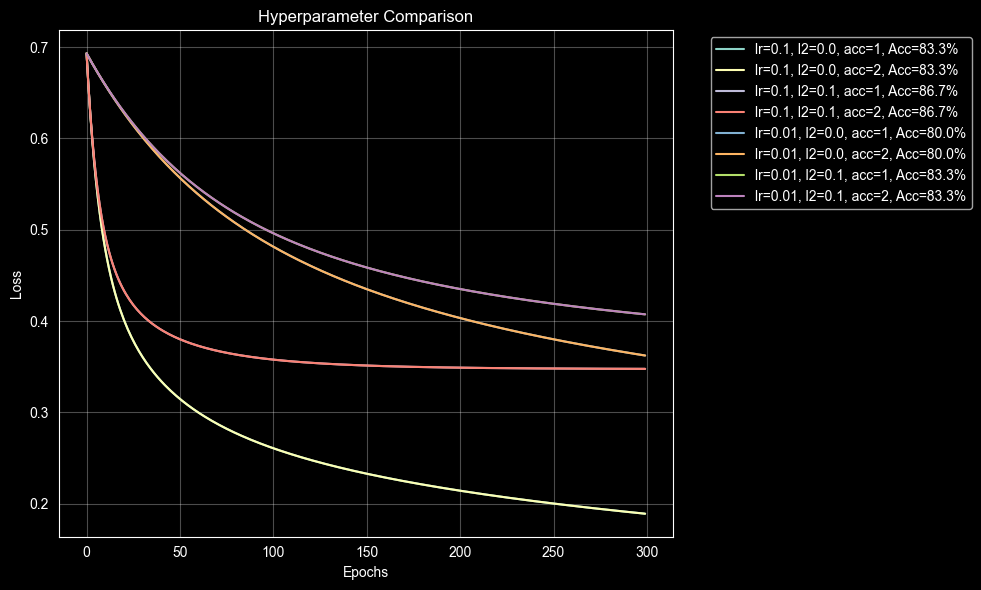

In [28]:
# TODO 5: 각 실험 조합에 대해 학습하고 결과를 시각화해봅시다.

results = {}

plt.figure(figsize=(10, 6))
for learning_rate, l2_strength, accumulate_step in experiments:
    W_exp, b_exp, loss_list = train_logistic_l2(
        X_train, y_train,
        learning_rate=learning_rate, epochs=300, l2=l2_strength
    )
    acc = accuracy(X_valid, W_exp, b_exp, y_valid)
    results[(learning_rate, l2_strength, accumulate_step)] = acc

    label = f"lr={learning_rate}, l2={l2_strength}, acc={accumulate_step}, Acc={acc*100:.1f}%"
    plt.plot(loss_list, label=label)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Hyperparameter Comparison")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

💡itertools.product 활용
> `product(A, B, C)`는 A, B, C의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">모든 가능한 조합</mark>을 생성합니다.</br>
> 3가지 변수 × 2개 값씩 = 총 $2^3 = 8$가지 실험을 자동으로 구성합니다.

</br>

## 결과 분석 포인트

<table style="width:100%">
  <thead>
    <tr>
      <th>관찰 항목</th>
      <th>확인 방법</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>수렴 속도</td><td>Loss 곡선이 빠르게 감소하는가?</td></tr>
    <tr><td>안정성</td><td>Loss 곡선이 진동 없이 매끄러운가?</td></tr>
    <tr><td>최종 성능</td><td>Validation Accuracy가 높은가?</td></tr>
    <tr><td>과적합 여부</td><td>Train과 Validation 성능 차이가 큰가?</td></tr>
  </tbody>
</table>

💡주의사항
> Loss 곡선이 발산하면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">학습률을 줄여보세요</mark>.</br>
> L2가 너무 크면 모델이 아무것도 학습하지 못할 수 있습니다.</br>
> 결과는 데이터 셔플링에 따라 달라질 수 있으므로 여러 번 실험하는 것이 좋습니다.